In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/hp/Downloads/Retail_AI_Control_Tower_Single_Table.csv")

print(df.shape)
df.head()

(2193000, 8)


,date,warehouse,product_id,units_sold,black_friday_flag,christmas_flag,category,lead_time_days
0,2024-01-01,London,1,15,0,0,Household,18
1,2024-01-02,London,1,14,0,0,Household,18
2,2024-01-03,London,1,12,0,0,Household,18
3,2024-01-04,London,1,16,0,0,Household,18
4,2024-01-05,London,1,9,0,0,Household,18


In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193000 entries, 0 to 2192999
Data columns (total 8 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   date               object
 1   warehouse          object
 2   product_id         int64 
 3   units_sold         int64 
 4   black_friday_flag  int64 
 5   christmas_flag     int64 
 6   category           object
 7   lead_time_days     int64 
dtypes: int64(5), object(3)
memory usage: 133.9+ MB


date                 0
warehouse            0
product_id           0
units_sold           0
black_friday_flag    0
christmas_flag       0
category             0
lead_time_days       0
dtype: int64

In [5]:
df['date'] = pd.to_datetime(df['date'])

print(df['date'].min())
print(df['date'].max())

2024-01-01 00:00:00
2025-12-31 00:00:00


In [6]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['week'] = df['date'].dt.isocalendar().week
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [7]:
df.head()

,date,warehouse,product_id,units_sold,black_friday_flag,christmas_flag,category,lead_time_days,year,month,quarter,week,day,day_of_week,is_weekend
0,2024-01-01,London,1,15,0,0,Household,18,2024,1,1,1,1,0,0
1,2024-01-02,London,1,14,0,0,Household,18,2024,1,1,1,2,1,0
2,2024-01-03,London,1,12,0,0,Household,18,2024,1,1,1,3,2,0
3,2024-01-04,London,1,16,0,0,Household,18,2024,1,1,1,4,3,0
4,2024-01-05,London,1,9,0,0,Household,18,2024,1,1,1,5,4,0


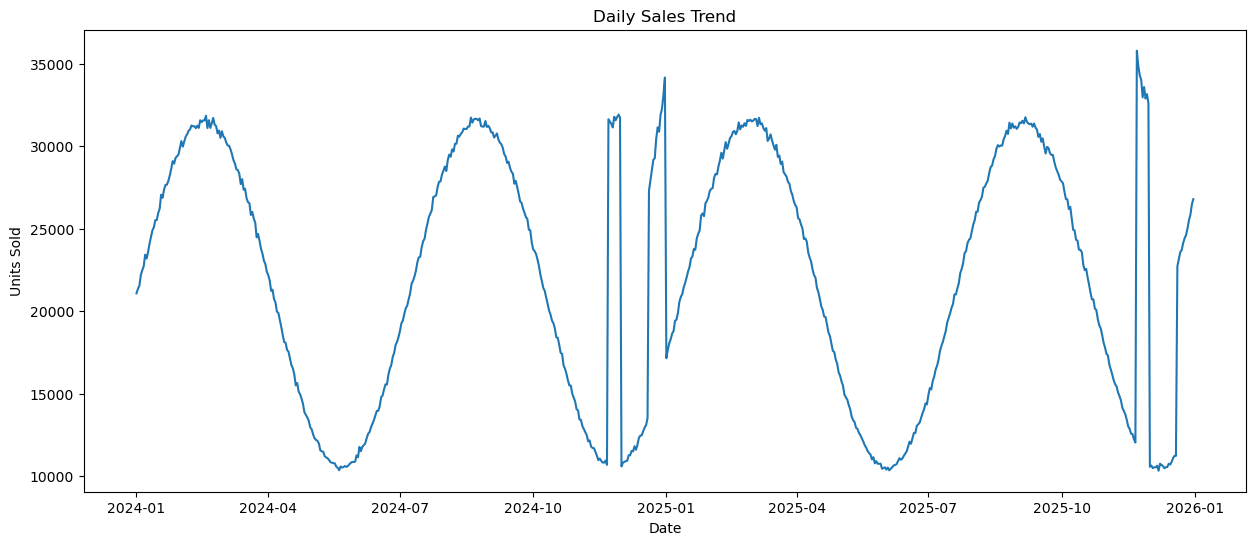

In [8]:
import matplotlib.pyplot as plt

daily_sales = (
    df.groupby('date')['units_sold']
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,6))
plt.plot(
    daily_sales['date'],
    daily_sales['units_sold']
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

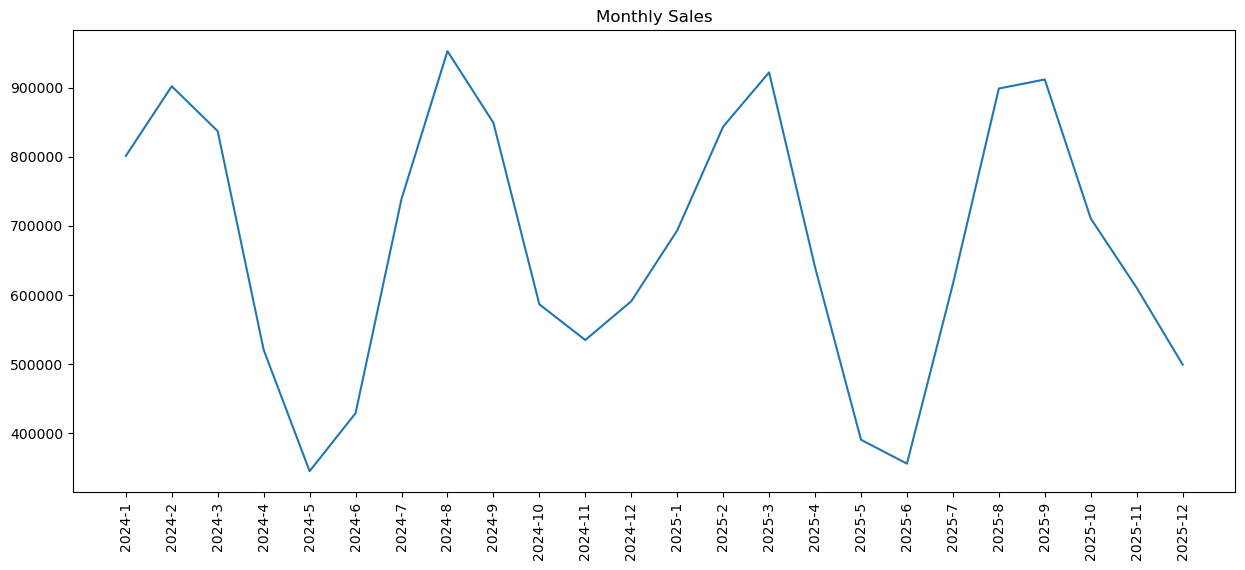

In [9]:
monthly_sales = (
    df.groupby(['year','month'])['units_sold']
    .sum()
    .reset_index()
)

monthly_sales['year_month'] = (
    monthly_sales['year'].astype(str)
    + "-"
    + monthly_sales['month'].astype(str)
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales['year_month'],
    monthly_sales['units_sold']
)

plt.xticks(rotation=90)

plt.title("Monthly Sales")
plt.show()

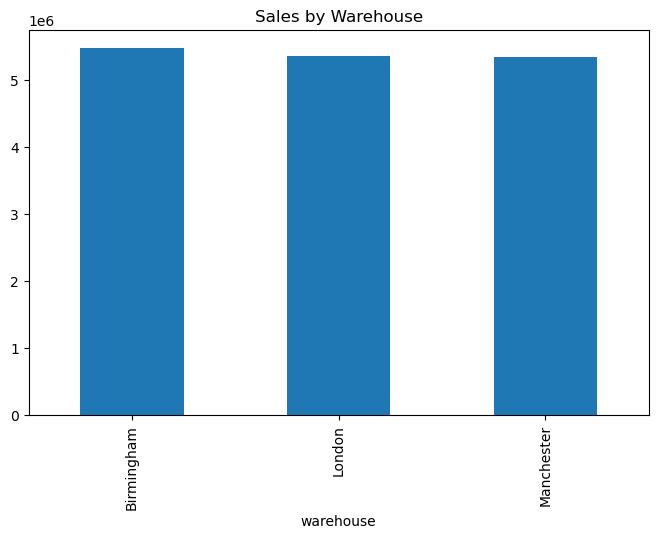

In [10]:
warehouse_sales = (
    df.groupby('warehouse')['units_sold']
    .sum()
    .sort_values(ascending=False)
)

warehouse_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Warehouse")
plt.show()

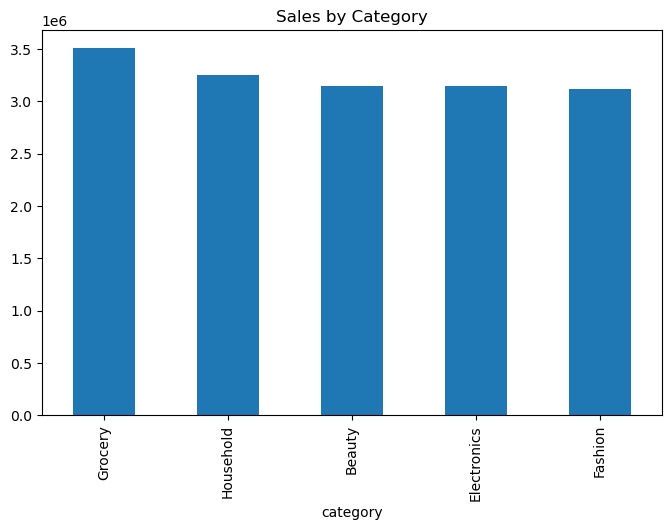

In [11]:
category_sales = (
    df.groupby('category')['units_sold']
    .sum()
    .sort_values(ascending=False)
)

category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.show()

In [12]:
bf_sales = (
    df.groupby('black_friday_flag')['units_sold']
    .mean()
)

print(bf_sales)

black_friday_flag
0     7.288616
1    10.902222
Name: units_sold, dtype: float64


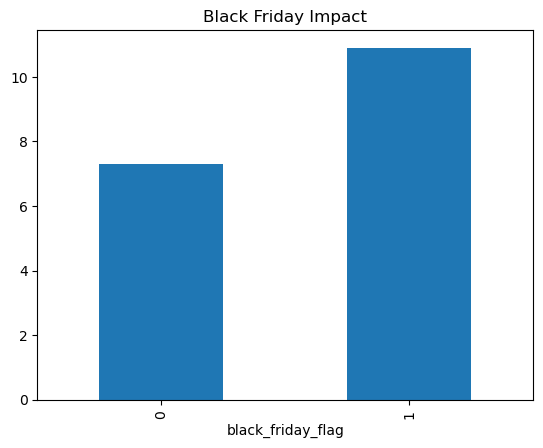

In [13]:
bf_sales.plot(
    kind='bar'
)

plt.title("Black Friday Impact")
plt.show()

christmas_flag
0    7.315715
1    9.200528
Name: units_sold, dtype: float64


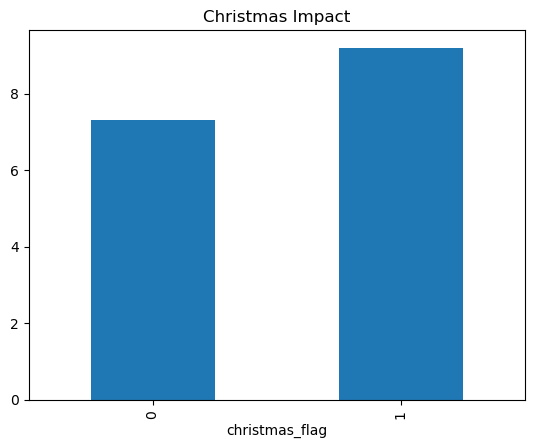

In [14]:
xmas_sales = (
    df.groupby('christmas_flag')['units_sold']
    .mean()
)

print(xmas_sales)

xmas_sales.plot(
    kind='bar'
)

plt.title("Christmas Impact")
plt.show()

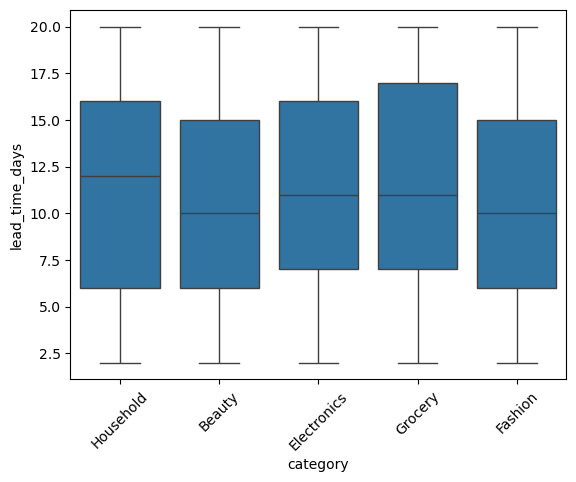

In [15]:
import seaborn as sns

sns.boxplot(
    x='category',
    y='lead_time_days',
    data=df
)

plt.xticks(rotation=45)
plt.show()

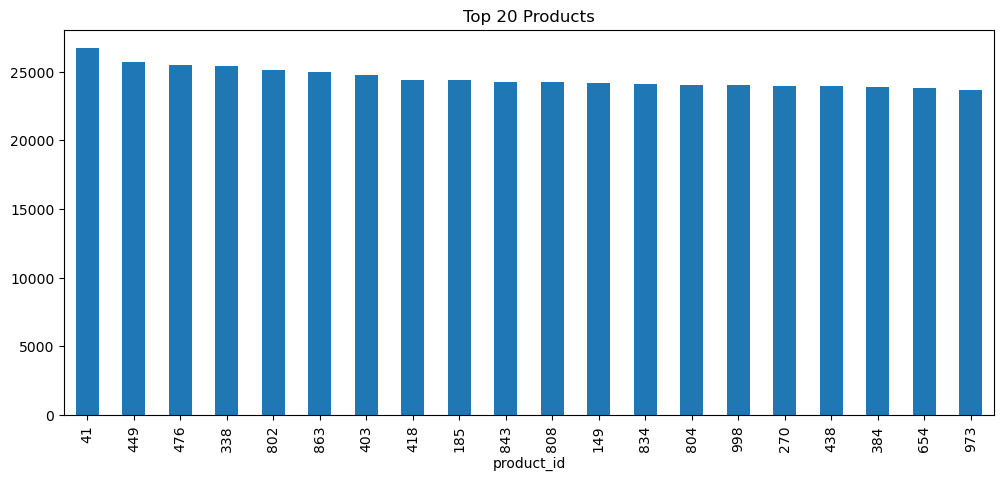

In [16]:
top_products = (
    df.groupby('product_id')['units_sold']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_products.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 20 Products")
plt.show()

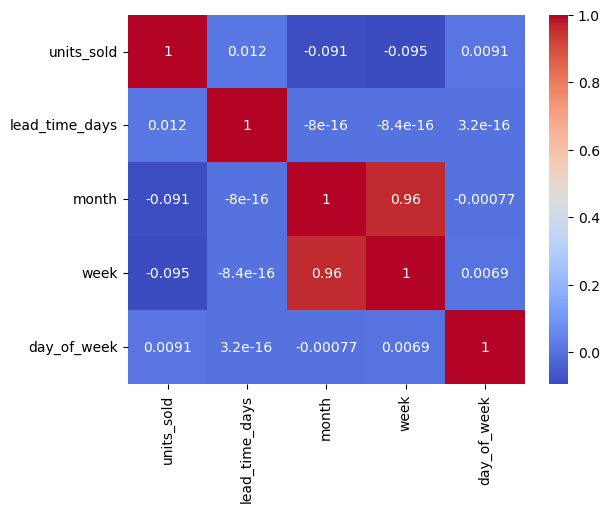

In [17]:
numeric_cols = [
    'units_sold',
    'lead_time_days',
    'month',
    'week',
    'day_of_week'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
#Feature Engineering 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("C:/Users/hp/Downloads/Retail_AI_Control_Tower_Single_Table.csv") #load data

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 2193000
Columns: 8


,date,warehouse,product_id,units_sold,black_friday_flag,christmas_flag,category,lead_time_days
0,2024-01-01,London,1,15,0,0,Household,18
1,2024-01-02,London,1,14,0,0,Household,18
2,2024-01-03,London,1,12,0,0,Household,18
3,2024-01-04,London,1,16,0,0,Household,18
4,2024-01-05,London,1,9,0,0,Household,18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193000 entries, 0 to 2192999
Data columns (total 8 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   date               object
 1   warehouse          object
 2   product_id         int64 
 3   units_sold         int64 
 4   black_friday_flag  int64 
 5   christmas_flag     int64 
 6   category           object
 7   lead_time_days     int64 
dtypes: int64(5), object(3)
memory usage: 133.9+ MB


In [5]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
missing = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percent': round(df.isnull().mean()*100,2)
})

missing.sort_values(
    'Percent',
    ascending=False
)

,Missing,Percent
date,0,0.0
warehouse,0,0.0
product_id,0,0.0
units_sold,0,0.0
black_friday_flag,0,0.0
christmas_flag,0,0.0
category,0,0.0
lead_time_days,0,0.0


In [7]:
duplicates = df.duplicated().sum()

print("Duplicates:", duplicates)

Duplicates: 0


In [8]:
df = df.drop_duplicates() #if duplicates exist

In [9]:
df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['quarter'] = df['date'].dt.quarter

df['week'] = df['date'].dt.isocalendar().week

df['day'] = df['date'].dt.day

df['day_of_week'] = df['date'].dt.dayofweek

df['day_name'] = df['date'].dt.day_name()

df['is_weekend'] = (
    df['day_of_week']
    .isin([5,6])
    .astype(int)
)

In [10]:
df.head()

,date,warehouse,product_id,units_sold,black_friday_flag,christmas_flag,category,lead_time_days,year,month,quarter,week,day,day_of_week,day_name,is_weekend
0,2024-01-01,London,1,15,0,0,Household,18,2024,1,1,1,1,0,Monday,0
1,2024-01-02,London,1,14,0,0,Household,18,2024,1,1,1,2,1,Tuesday,0
2,2024-01-03,London,1,12,0,0,Household,18,2024,1,1,1,3,2,Wednesday,0
3,2024-01-04,London,1,16,0,0,Household,18,2024,1,1,1,4,3,Thursday,0
4,2024-01-05,London,1,9,0,0,Household,18,2024,1,1,1,5,4,Friday,0


In [ ]:
#Target Variable Analysis


In [11]:
df['units_sold'].describe()

count    2.193000e+06
mean     7.377596e+00
std      4.967913e+00
min      0.000000e+00
25%      4.000000e+00
50%      6.000000e+00
75%      1.000000e+01
max      4.800000e+01
Name: units_sold, dtype: float64

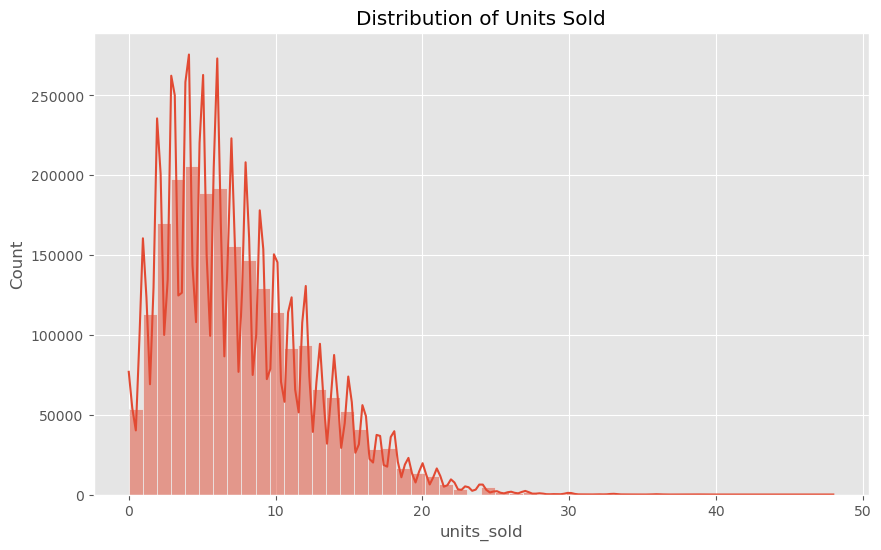

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['units_sold'],
    bins=50,
    kde=True
)

plt.title("Distribution of Units Sold")

plt.show()

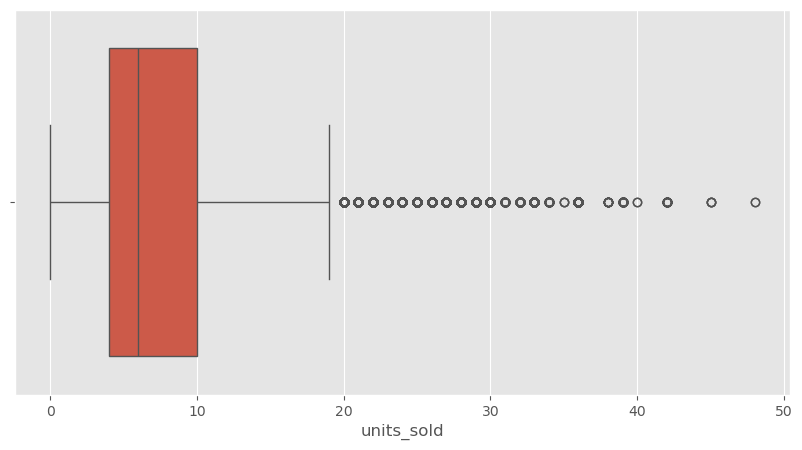

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['units_sold']
)

plt.show()

In [ ]:
#time series analysis

In [14]:
daily_sales = (
    df.groupby('date')['units_sold']
      .sum()
      .reset_index()
)

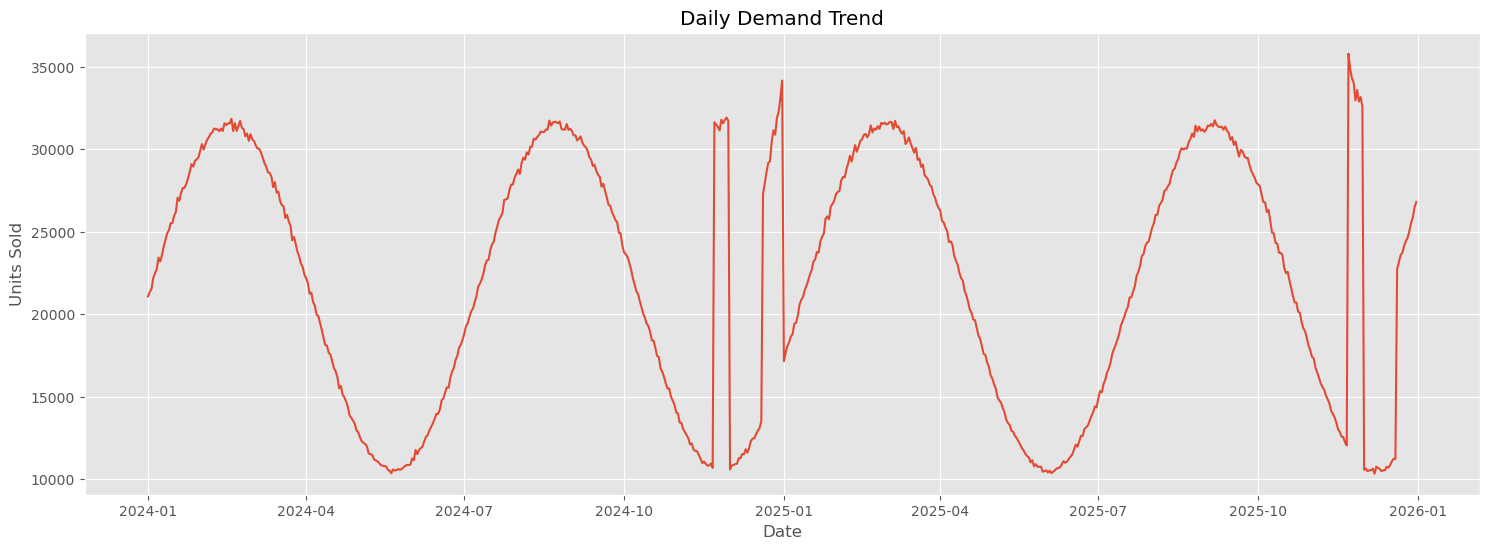

In [15]:
plt.figure(figsize=(18,6))

plt.plot(
    daily_sales['date'],
    daily_sales['units_sold']
)

plt.title("Daily Demand Trend")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.show()

In [17]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key='date',
            freq='ME'
        )
    )['units_sold']
    .sum()
)

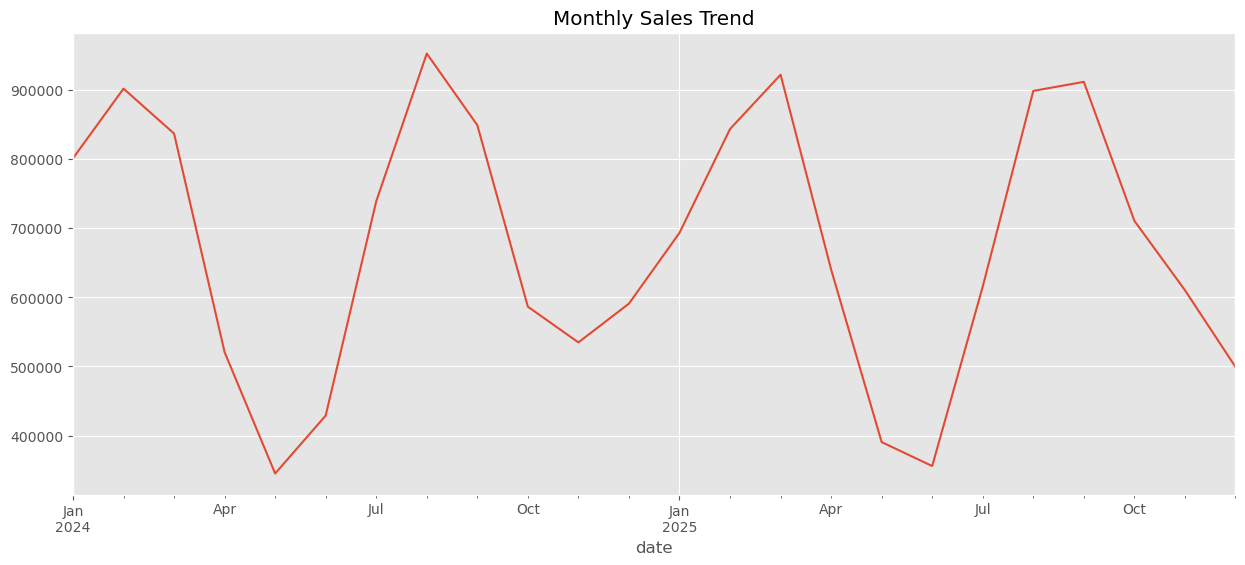

In [18]:
plt.figure(figsize=(15,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.show()

In [19]:
warehouse_sales = (
    df.groupby('warehouse')
      ['units_sold']
      .sum()
      .sort_values(
          ascending=False
      )
)

warehouse_sales

warehouse
Birmingham    5476887
London        5362685
Manchester    5339497
Name: units_sold, dtype: int64

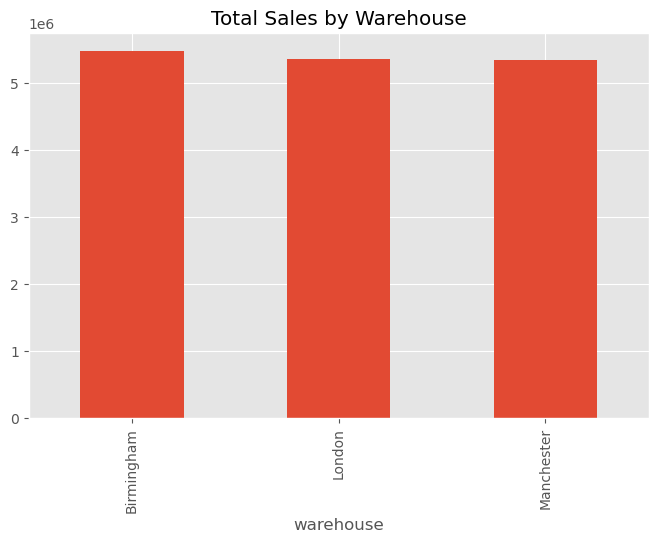

In [20]:
warehouse_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Total Sales by Warehouse"
)

plt.show()

In [21]:
category_sales = (
    df.groupby('category')
      ['units_sold']
      .sum()
      .sort_values(
          ascending=False
      )
)

category_sales

category
Grocery        3506893
Household      3253965
Beauty         3151696
Electronics    3151452
Fashion        3115063
Name: units_sold, dtype: int64

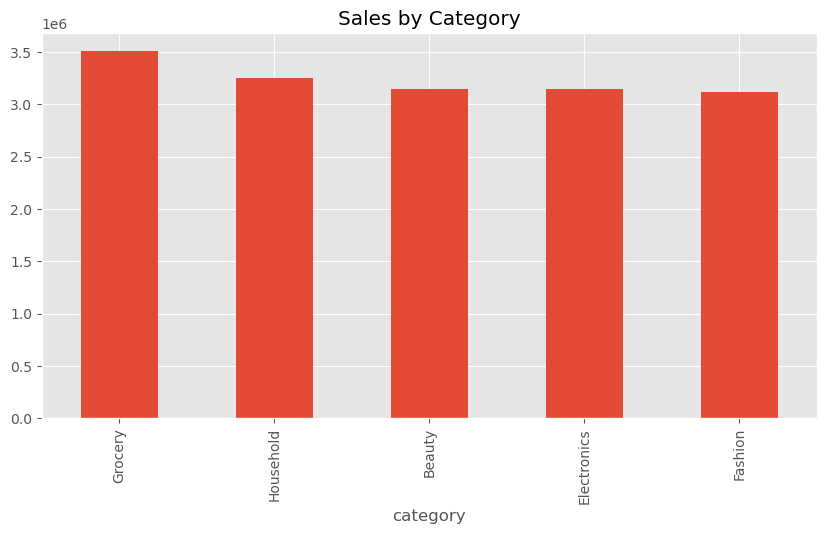

In [22]:
category_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Sales by Category"
)

plt.show()

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

!pip install xgboost

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 6.4 MB/s eta 0:00:11
   - -------------------------------------- 2.4/69.5 MB 7.8 MB/s eta 0:00:09
   -- ------------------------------------- 4.2/69.5 MB 8.3 MB/s eta 0:00:08
   --- ------------------------------------ 5.5/69.5 MB 7.6 MB/s eta 0:00:09
   ---- ----------------------------------- 7.3/69.5 MB 7.7 MB/s eta 0:00:09
   ----- ---------------------------------- 9.2/69.5 MB 7.9 MB/s eta 0:00:08
   ----- ---------------------------------- 10.2/69.5 MB 7.5 MB/s eta 0:00:08
   ------ --------------------------------- 11.3/69.5 MB 7.6 MB/s eta 0:00:08
   ------- -------------------------------- 12.3/69.5 MB 7.7 MB/s eta 0:00:08
   ------- -------------------------------- 13.6/69.5 MB 6.8 MB/s eta 0:00:09
   -------- ------------------------------- 15.2/69.5 MB 6.9 MB/s eta 0:00:08
   --------- ------------------------------ 17.3/69.5 MB 7.1 MB/s eta 0:00:08


In [26]:
df = pd.read_csv("C:/Users/hp/Downloads/Retail_AI_Control_Tower_Single_Table.csv")


df['date'] = pd.to_datetime(df['date'])

In [27]:
df = df.sort_values(
    ['product_id','date']
)

In [28]:
df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['quarter'] = df['date'].dt.quarter

df['week'] = df['date'].dt.isocalendar().week

df['day'] = df['date'].dt.day

df['dayofweek'] = df['date'].dt.dayofweek

df['is_weekend'] = (
    df['dayofweek']
    .isin([5,6])
    .astype(int)
)

In [29]:
df['lag_1'] = (
    df.groupby('product_id')
      ['units_sold']
      .shift(1)
)

df['lag_7'] = (
    df.groupby('product_id')
      ['units_sold']
      .shift(7)
)

df['lag_14'] = (
    df.groupby('product_id')
      ['units_sold']
      .shift(14)
)

df['lag_30'] = (
    df.groupby('product_id')
      ['units_sold']
      .shift(30)
)

In [30]:
df['rolling_7'] = (
    df.groupby('product_id')
      ['units_sold']
      .transform(
          lambda x:
          x.shift(1)
           .rolling(7)
           .mean()
      )
)

df['rolling_30'] = (
    df.groupby('product_id')
      ['units_sold']
      .transform(
          lambda x:
          x.shift(1)
           .rolling(30)
           .mean()
      )
)

In [31]:
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'warehouse',
    'product_id',
    'category'
]

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

In [32]:
features = [

    'warehouse',
    'product_id',
    'category',

    'lead_time_days',

    'black_friday_flag',
    'christmas_flag',

    'year',
    'month',
    'quarter',
    'week',
    'day',
    'dayofweek',
    'is_weekend',

    'lag_1',
    'lag_7',
    'lag_14',
    'lag_30',

    'rolling_7',
    'rolling_30'
]

target = 'units_sold'

In [33]:
split_date = "2025-10-01"

train = df[
    df['date'] < split_date
]

test = df[
    df['date'] >= split_date
]

In [34]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [35]:
model = XGBRegressor(

    n_estimators=300,

    max_depth=8,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [36]:
preds = model.predict(
    X_test
)

In [37]:
mae = mean_absolute_error(
    y_test,
    preds
)

print("MAE:", round(mae,2))

MAE: 2.64


In [38]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

print("RMSE:", round(rmse,2))

RMSE: 3.59


In [39]:
mape = (
    np.mean(
        np.abs(
            (y_test - preds)
            /
            y_test
        )
    )
) * 100

print(
    "MAPE:",
    round(mape,2),
    "%"
)

MAPE: inf %


In [40]:
comparison = pd.DataFrame({

    'Actual': y_test.values,
    'Predicted': preds

})

comparison = comparison.head(500)

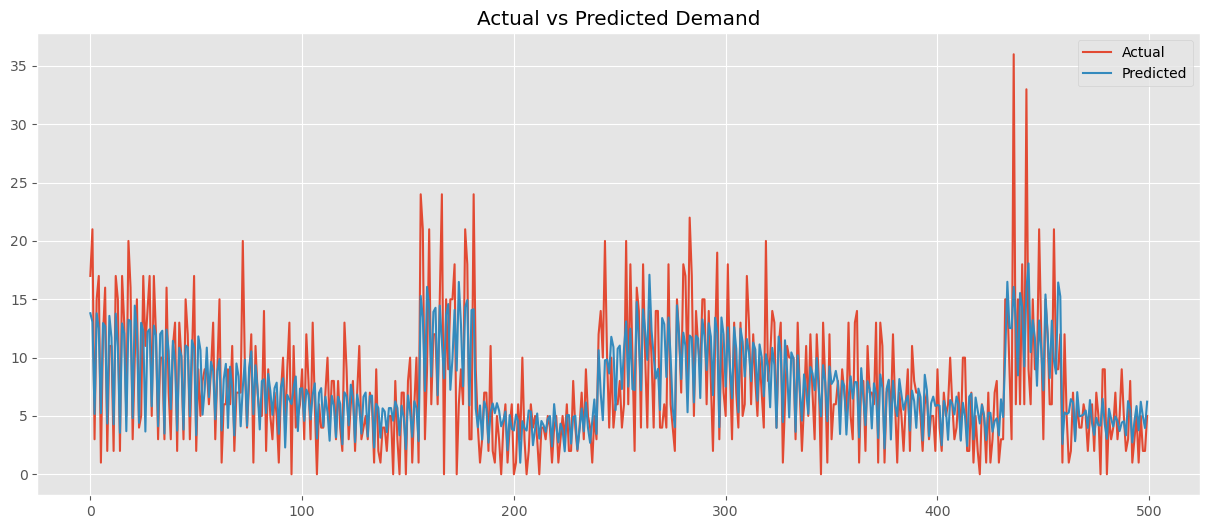

In [41]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Predicted'],
    label='Predicted'
)

plt.legend()

plt.title(
    'Actual vs Predicted Demand'
)

plt.show()

In [42]:
importance = pd.DataFrame({

    'Feature': features,

    'Importance': model.feature_importances_

})

importance = (
    importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

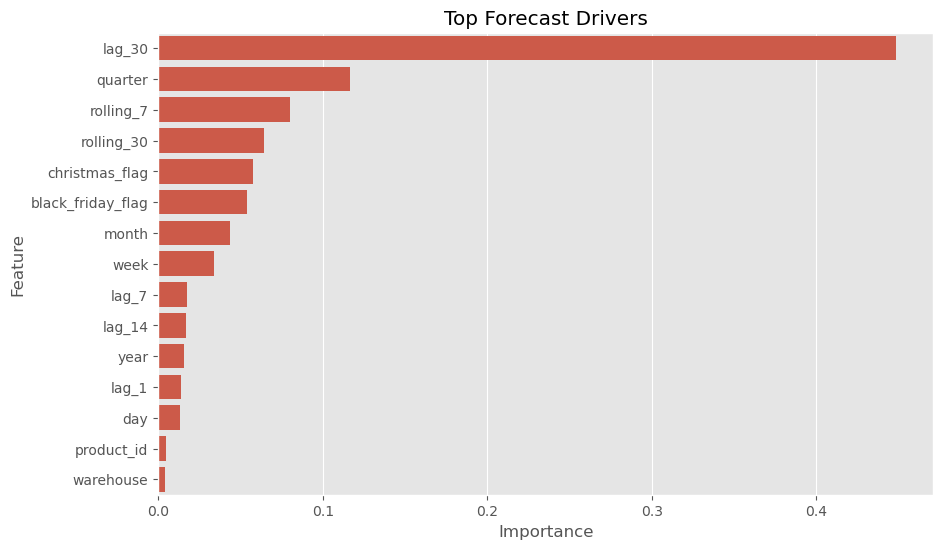

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(15),

    x='Importance',

    y='Feature'
)

plt.title(
    'Top Forecast Drivers'
)

plt.show()